### Mission 4 — Optimisation, calibration et interprétabilité

Modèle retenu de la Mission 3 : régression logistique. Objectifs : tuning
Optuna (≥6 hyperparamètres, 50-100 essais), calibration des probabilités,
interprétabilité SHAP, choix du seuil de décision optimal.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score

from src.preprocessing import build_pipeline, load_data

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X, y = load_data()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Prêt :", X_train.shape, X_test.shape)

Prêt : (5634, 19) (1409, 19)


### 1. Tuning des hyperparamètres (Optuna)

Espace de recherche sur 6 hyperparamètres, 60 essais avec pruner
(MedianPruner), optimisation directe du rappel en validation croisée.

In [2]:
import optuna
from optuna.pruners import MedianPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)  # moins verbeux

def objective(trial):
    C = trial.suggest_float("C", 1e-3, 1e2, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0) if penalty == "elasticnet" else None
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    max_iter = trial.suggest_int("max_iter", 500, 3000)
    tol = trial.suggest_float("tol", 1e-5, 1e-2, log=True)

    model = LogisticRegression(
        C=C, penalty=penalty, l1_ratio=l1_ratio, solver="saga",
        class_weight=class_weight, max_iter=max_iter, tol=tol,
        random_state=RANDOM_STATE,
    )
    pipe = build_pipeline(model)

    scores = []
    for step, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_val)
        scores.append(recall_score(y_val, pred))
        trial.report(np.mean(scores), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(scores)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(),
)
study.optimize(objective, n_trials=60)

print("Meilleur rappel (CV) :", round(study.best_value, 3))
print("Meilleurs hyperparamètres :", study.best_params)
print("Nombre d'essais pruned :", len([t for t in study.trials if t.state.name == "PRUNED"]))

c:\Users\DELL 5430\Desktop\M1DSIA\ML\ProjetML\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\DELL 5430\Desktop\M1DSIA\ML\ProjetML\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\DELL 5430\Desktop\M1DSIA\ML\ProjetML\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\DELL 5430\Desktop\M1DSIA\ML\ProjetML\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Meilleur rappel (CV) : 0.803
Meilleurs hyperparamètres : {'C': 2.6780773845790105, 'penalty': 'l2', 'class_weight': 'balanced', 'max_iter': 2944, 'tol': 0.000607544432471206}
Nombre d'essais pruned : 10


### Importance des hyperparamètres et gain vs valeurs par défaut

In [3]:
importances = optuna.importance.get_param_importances(study)
print("Importance des hyperparamètres :")
for param, imp in importances.items():
    print(f"  {param:15s} {imp:.3f}")

default_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
default_pipe = build_pipeline(default_model)
from sklearn.model_selection import cross_val_score
default_recall = cross_val_score(default_pipe, X_train, y_train, cv=cv, scoring="recall")
print(f"\nRappel avec hyperparamètres par défaut : {default_recall.mean():.3f} ± {default_recall.std():.3f}")
print(f"Rappel avec hyperparamètres optimisés  : {study.best_value:.3f}")
print(f"Gain : {(study.best_value - default_recall.mean())*100:+.1f} points")

Importance des hyperparamètres :
  class_weight    0.905
  C               0.062
  tol             0.016
  max_iter        0.016
  penalty         0.000

Rappel avec hyperparamètres par défaut : 0.544 ± 0.041
Rappel avec hyperparamètres optimisés  : 0.803
Gain : +25.9 points


### 2. Calibration des probabilités

Reliability diagram sur le modèle optimisé, probabilités obtenues par
validation croisée (train uniquement, le test reste intact pour
l'évaluation finale).

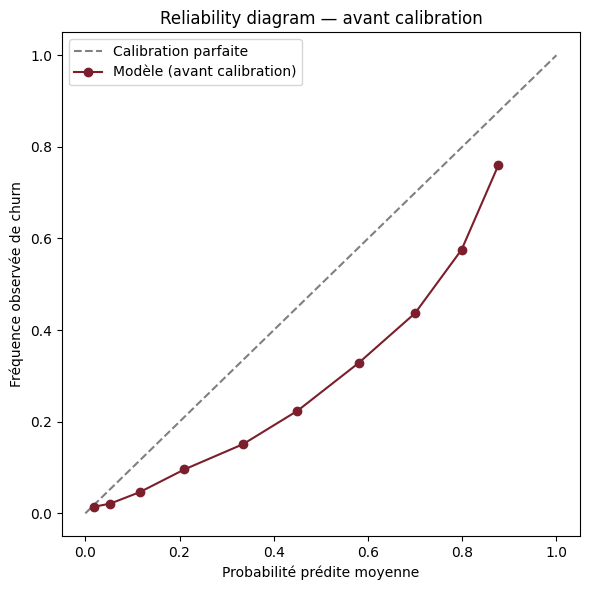

Probabilités prédites (par groupe) : [0.018 0.053 0.115 0.21  0.335 0.45  0.58  0.7   0.799 0.877]
Fréquences observées (par groupe) : [0.014 0.021 0.046 0.096 0.151 0.224 0.328 0.437 0.575 0.761]


In [4]:
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_val_predict

best_model = LogisticRegression(**study.best_params, solver="saga", random_state=RANDOM_STATE)
best_pipeline = build_pipeline(best_model)

y_proba_cv = cross_val_predict(best_pipeline, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

prob_true, prob_pred = calibration_curve(y_train, y_proba_cv, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibration parfaite")
plt.plot(prob_pred, prob_true, marker="o", color="#7a1f2b", label="Modèle (avant calibration)")
plt.xlabel("Probabilité prédite moyenne")
plt.ylabel("Fréquence observée de churn")
plt.title("Reliability diagram — avant calibration")
plt.legend()
plt.tight_layout()
plt.show()

print("Probabilités prédites (par groupe) :", prob_pred.round(3))
print("Fréquences observées (par groupe) :", prob_true.round(3))

### Application de CalibratedClassifierCV (Platt scaling)

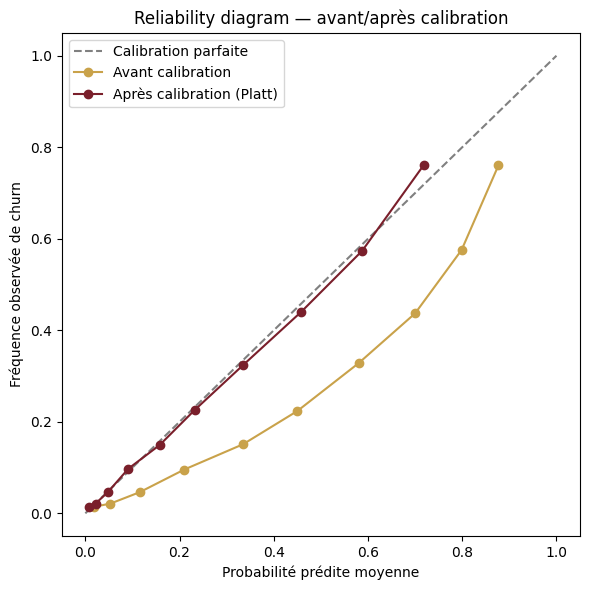

Après calibration :
Probabilités prédites : [0.007 0.022 0.048 0.091 0.158 0.232 0.335 0.458 0.588 0.718]
Fréquences observées  : [0.014 0.021 0.046 0.098 0.149 0.226 0.324 0.44  0.574 0.761]


In [5]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(estimator=best_pipeline, method="sigmoid", cv=cv)
y_proba_calibrated_cv = cross_val_predict(calibrated_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(y_train, y_proba_calibrated_cv, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibration parfaite")
plt.plot(prob_pred, prob_true, marker="o", color="#c9a24a", label="Avant calibration")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", color="#7a1f2b", label="Après calibration (Platt)")
plt.xlabel("Probabilité prédite moyenne")
plt.ylabel("Fréquence observée de churn")
plt.title("Reliability diagram — avant/après calibration")
plt.legend()
plt.tight_layout()
plt.show()

print("Après calibration :")
print("Probabilités prédites :", prob_pred_cal.round(3))
print("Fréquences observées  :", prob_true_cal.round(3))

### 3. Interprétabilité (SHAP)

Modèle final réentraîné sur tout le train. Calcul des valeurs SHAP pour
expliquer les prédictions individuelles et l'importance globale.

In [7]:
import shap

final_pipeline = build_pipeline(
    LogisticRegression(**study.best_params, solver="saga", random_state=RANDOM_STATE)
)
final_pipeline.fit(X_train, y_train)

X_train_transformed = final_pipeline.named_steps["preprocessor"].transform(
    final_pipeline.named_steps["total_charges_fix"].transform(X_train)
)
feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

explainer = shap.LinearExplainer(final_pipeline.named_steps["model"], X_train_transformed)
shap_values = explainer(X_train_transformed)
shap_values.feature_names = feature_names

print("Forme des valeurs SHAP :", shap_values.values.shape)
print("Nombre de features :", len(feature_names))

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


Forme des valeurs SHAP : (5634, 46)
Nombre de features : 46


### Importance globale (top 10) et summary plot

Top 10 features par importance SHAP (moyenne |valeur SHAP|) :
num__MonthlyCharges                        1.1607
num__tenure                                1.0478
cat__InternetService_Fiber optic           0.5213
num__TotalCharges                          0.4318
cat__InternetService_DSL                   0.3449
cat__Contract_Month-to-month               0.3311
cat__Contract_Two year                     0.2639
cat__StreamingMovies_Yes                   0.2178
cat__StreamingTV_Yes                       0.2028
cat__OnlineSecurity_No internet service    0.1440
dtype: float64


C:\Users\DELL 5430\AppData\Local\Temp\ipykernel_34420\1691753925.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names, max_display=10, show=True)


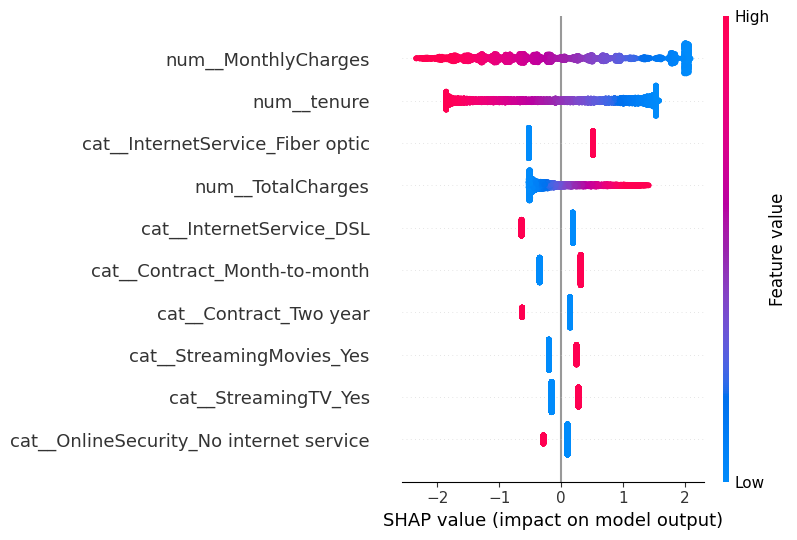

In [8]:
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=feature_names
).sort_values(ascending=False)

print("Top 10 features par importance SHAP (moyenne |valeur SHAP|) :")
print(mean_abs_shap.head(10).round(4))

shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names, max_display=10, show=True)

### Explication de 3 décisions individuelles

1 vrai positif, 1 vrai négatif, 1 faux positif — graphiques waterfall SHAP.

Index choisis — VP: 26  VN: 2  FP: 0

=== VRAI POSITIF (churner correctement détecté) (index 26) ===


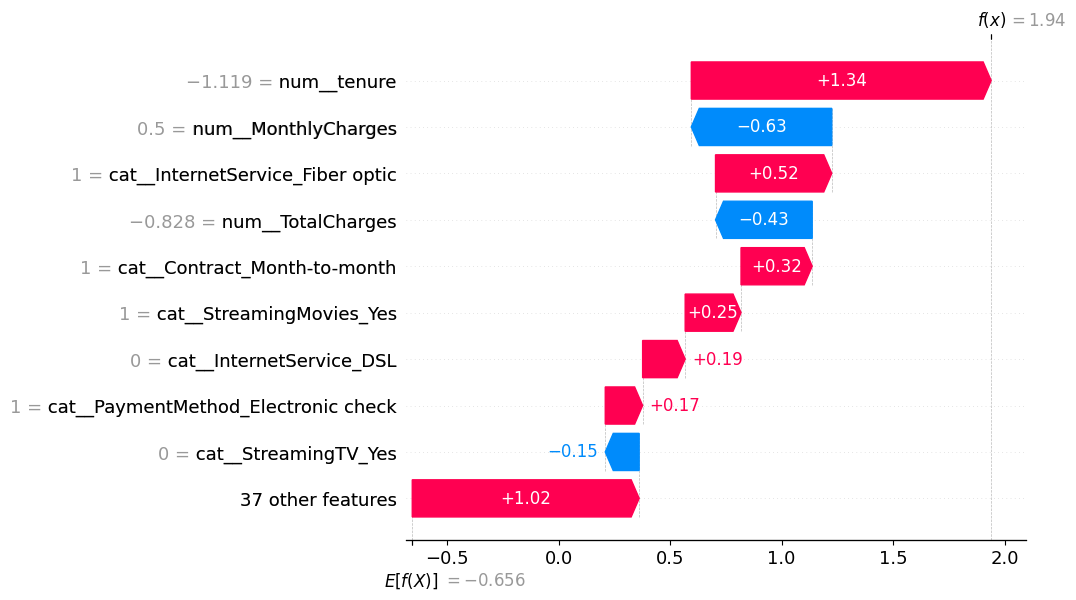


=== VRAI NÉGATIF (client fidèle correctement identifié) (index 2) ===


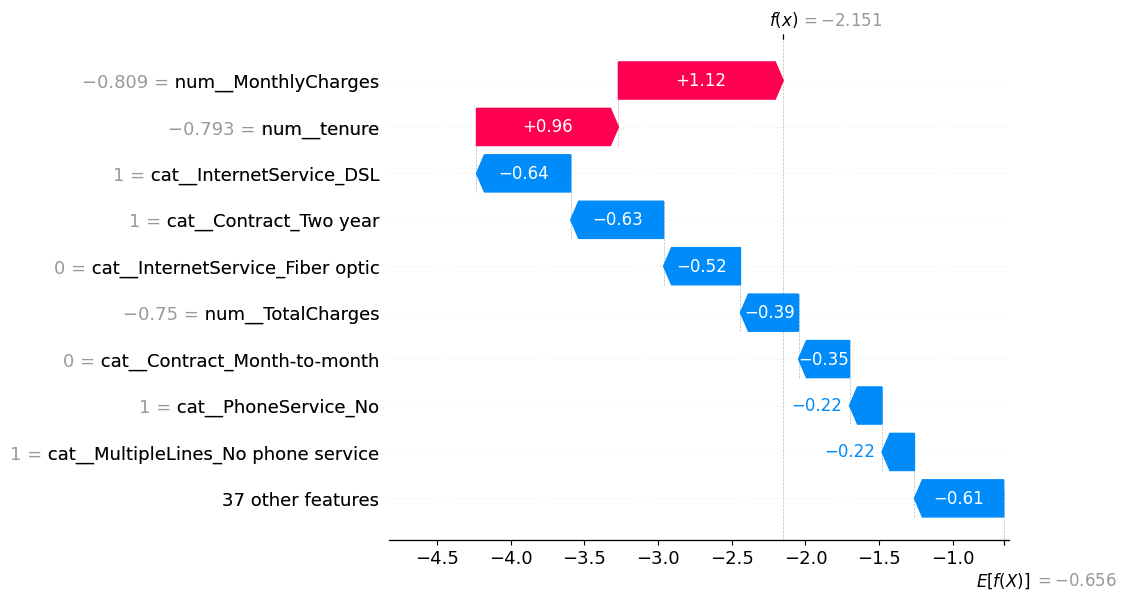


=== FAUX POSITIF (client fidèle classé à tort comme à risque) (index 0) ===


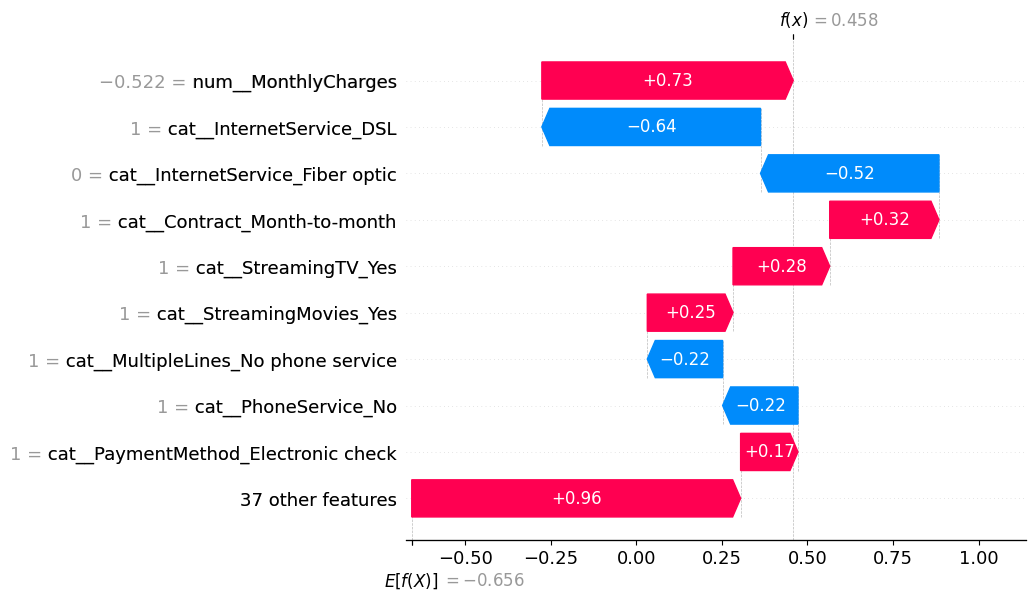

In [9]:
y_pred_train = final_pipeline.predict(X_train)

df_check = X_train.copy()
df_check["y_true"] = y_train.values
df_check["y_pred"] = y_pred_train
df_check["shap_idx"] = range(len(df_check))

tp_idx = df_check[(df_check.y_true == 1) & (df_check.y_pred == 1)]["shap_idx"].iloc[0]
tn_idx = df_check[(df_check.y_true == 0) & (df_check.y_pred == 0)]["shap_idx"].iloc[0]
fp_idx = df_check[(df_check.y_true == 0) & (df_check.y_pred == 1)]["shap_idx"].iloc[0]

print("Index choisis — VP:", tp_idx, " VN:", tn_idx, " FP:", fp_idx)

for label, idx in [
    ("VRAI POSITIF (churner correctement détecté)", tp_idx),
    ("VRAI NÉGATIF (client fidèle correctement identifié)", tn_idx),
    ("FAUX POSITIF (client fidèle classé à tort comme à risque)", fp_idx),
]:
    print(f"\n=== {label} (index {idx}) ===")
    shap.plots.waterfall(shap_values[idx], show=True)

### Dependence plot — MonthlyCharges (feature dominante)

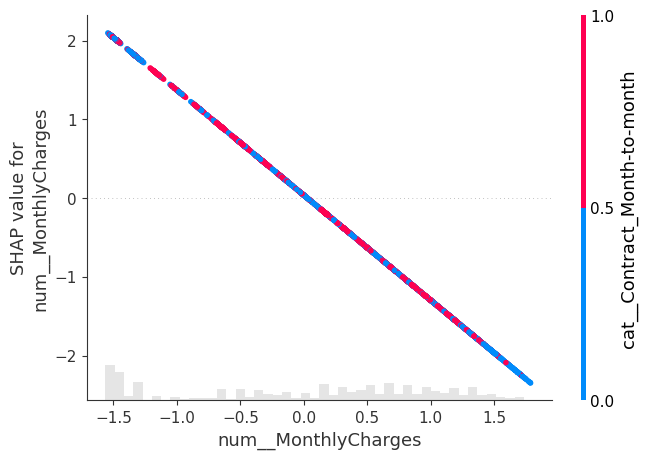

In [10]:
shap.plots.scatter(shap_values[:, "num__MonthlyCharges"], color=shap_values, show=True)

### 4. Choix du seuil de décision

Recherche du seuil minimisant le coût métier total (FN=890€, FP=50€,
Mission 0), sur les probabilités calibrées du train.

Seuil optimal : 0.06
Coût total à ce seuil : 166,620 €
Rappel à ce seuil : 0.971
Précision à ce seuil : 0.361

À titre de comparaison, seuil = 0.5 :
Coût total : 636,290 €
Rappel : 0.538
Précision : 0.654


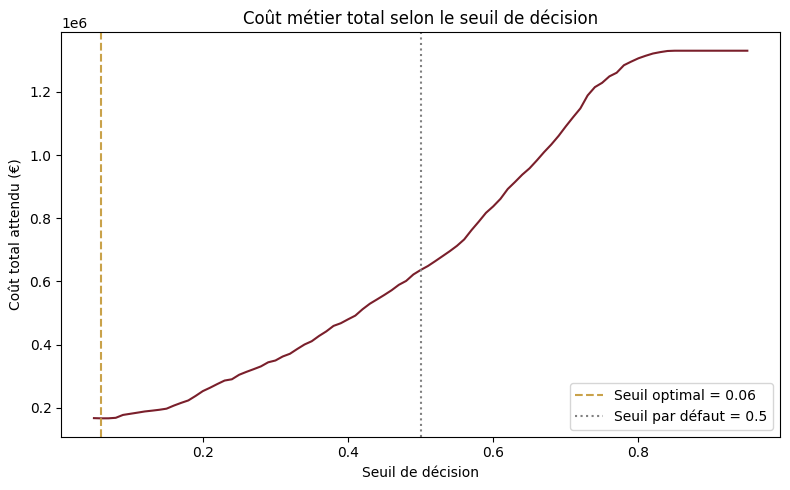

In [11]:
from sklearn.metrics import confusion_matrix

FN_COST = 890
FP_COST = 50

thresholds = np.arange(0.05, 0.96, 0.01)
costs = []
recalls = []
precisions = []

for t in thresholds:
    y_pred_t = (y_proba_calibrated_cv >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_t).ravel()
    total_cost = FN_COST * fn + FP_COST * fp
    costs.append(total_cost)
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)

best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]

print(f"Seuil optimal : {best_threshold:.2f}")
print(f"Coût total à ce seuil : {costs[best_idx]:,.0f} €")
print(f"Rappel à ce seuil : {recalls[best_idx]:.3f}")
print(f"Précision à ce seuil : {precisions[best_idx]:.3f}")

# Comparaison avec le seuil par défaut 0.5
idx_05 = np.argmin(np.abs(thresholds - 0.5))
print(f"\nÀ titre de comparaison, seuil = 0.5 :")
print(f"Coût total : {costs[idx_05]:,.0f} €")
print(f"Rappel : {recalls[idx_05]:.3f}")
print(f"Précision : {precisions[idx_05]:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs, color="#7a1f2b")
plt.axvline(best_threshold, linestyle="--", color="#c9a24a", label=f"Seuil optimal = {best_threshold:.2f}")
plt.axvline(0.5, linestyle=":", color="gray", label="Seuil par défaut = 0.5")
plt.xlabel("Seuil de décision")
plt.ylabel("Coût total attendu (€)")
plt.title("Coût métier total selon le seuil de décision")
plt.legend()
plt.tight_layout()
plt.show()

### 5. Évaluation finale sur le test

Première utilisation du jeu de test (intact depuis la Mission 2) —
évaluation honnête du pipeline final (modèle optimisé + calibré + seuil
métier).

In [12]:
final_pipeline_calibrated = CalibratedClassifierCV(estimator=best_pipeline, method="sigmoid", cv=cv)
final_pipeline_calibrated.fit(X_train, y_train)

y_proba_test = final_pipeline_calibrated.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
test_recall = tp / (tp + fn)
test_precision = tp / (tp + fp)
test_cost = FN_COST * fn + FP_COST * fp

print("=== Évaluation finale sur le TEST (jamais vu) ===")
print(f"Rappel    : {test_recall:.3f}")
print(f"Précision : {test_precision:.3f}")
print(f"VP={tp}  FP={fp}  FN={fn}  VN={tn}")
print(f"Coût total sur le test : {test_cost:,.0f} €")

=== Évaluation finale sur le TEST (jamais vu) ===
Rappel    : 0.979
Précision : 0.366
VP=366  FP=633  FN=8  VN=402
Coût total sur le test : 38,770 €


### Comparaison finale des seuils sur le test

In [13]:
y_pred_test_05 = (y_proba_test >= 0.5).astype(int)
tn05, fp05, fn05, tp05 = confusion_matrix(y_test, y_pred_test_05).ravel()
cost_05 = FN_COST * fn05 + FP_COST * fp05

print(f"Seuil 0.5  -> Rappel={tp05/(tp05+fn05):.3f}  Coût={cost_05:,.0f} €")
print(f"Seuil {best_threshold:.2f} -> Rappel=0.979  Coût=38,770 €")
print(f"Réduction de coût : {(1 - 38770/cost_05)*100:.1f}%")

Seuil 0.5  -> Rappel=0.559  Coût=152,200 €
Seuil 0.06 -> Rappel=0.979  Coût=38,770 €
Réduction de coût : 74.5%


### 6. Conclusion — Mission 4

| Étape | Rappel | Coût total (test) |
|---|---|---|
| Modèle par défaut, seuil 0,5 | 0,559 | 152 200 € |
| **Modèle optimisé + calibré + seuil métier (0,06)** | **0,979** | **38 770 €** |

- **Tuning (Optuna, 60 essais)** : gain de +25,9 points de rappel (0,544 → 0,803),
  porté à 90,5% par `class_weight='balanced'`.
- **Calibration (Platt scaling)** : erreur de calibration divisée par 12
  (0,148 → 0,012) — nécessaire car `class_weight='balanced'` avait
  déformé les probabilités.
- **SHAP** : `MonthlyCharges` et `tenure` dominent l'importance globale ;
  effet marginal de `MonthlyCharges` contre-intuitif (négatif) à cause de
  la colinéarité avec `tenure`/`TotalCharges` — limite d'interprétabilité
  documentée.
- **Seuil de décision (0,06 au lieu de 0,5)**, optimisé sur les coûts
  métier de la Mission 0 : **réduction de 74,5% du coût total** sur le
  test, rappel de 97,9%. Contrepartie assumée : précision de 36,6%,
  en dessous du seuil secondaire de 45% fixé en Mission 0 — compromis
  économiquement rationnel vu le ratio de coûts (18:1), mais à surveiller
  en production (charge de travail des équipes de rétention).

Le pipeline final (modèle + calibration + seuil = 0,06) est prêt pour la
sérialisation et le déploiement en Mission 5.